# Experimento de Correlación: Precipitación vs. Eventos Hidrometeorológicos en Colombia

**Objetivo:** Verificar si las fuentes de datos públicas (IDEAM + UNGRD) permiten identificar
una correlación estadísticamente significativa entre la precipitación acumulada y la ocurrencia
de eventos hidrometeorológicos extremos (avenidas torrenciales, crecientes, inundaciones y deslizamientos).

**Fuentes:**
- Precipitaciones: IDEAM via datos.gov.co (`s54a-sgyg`) — sensores automáticos en mm
- Eventos: UNGRD via datos.gov.co (`wwkg-r6te`) — emergencias 2019-2022

**Pregunta central:** ¿La precipitación acumulada previa predice la ocurrencia de eventos hidrometeorológicos extremos?

In [1]:
import sys
print(sys.executable)

c:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\.venv\Scripts\python.exe


In [2]:
import sys
from pathlib import Path

_cwd = Path().resolve()
for _p in [_cwd, *_cwd.parents]:
    if (_p / "pyproject.toml").exists():
        _root = _p
        break
else:
    _root = _cwd.parent

sys.path.insert(0, str(_root / "src"))
print(f"Project root : {_root}")
print(f"sys.path[0]  : {sys.path[0]}")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from experiment.download import load_ideam, load_ungrd
from experiment.process import clean_ideam, clean_ungrd, aggregate_monthly, build_features, save_processed

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente.')

Project root : C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops
sys.path[0]  : C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\src


ImportError: cannot import name 'aggregate_monthly' from 'experiment.process' (C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\src\experiment\process.py)

## 1. Carga de Datos

In [ ]:
df_ideam_raw = load_ideam(anio_inicio=2019, anio_fin=2022)
df_ungrd_raw = load_ungrd()

print(f'\nIDEAM shape: {df_ideam_raw.shape}')
print(f'UNGRD shape: {df_ungrd_raw.shape}')

Cargando IDEAM desde cache: D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops\data\raw\ideam_precipitaciones.csv
Cargando UNGRD desde cache: D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops\data\raw\ungrd_emergencias.csv

IDEAM shape: (240000, 3)
UNGRD shape: (25857, 71)


In [ ]:
print('=== IDEAM — primeras filas ===')
display(df_ideam_raw.head(3))
print('\n=== UNGRD — primeras filas ===')
display(df_ungrd_raw.head(3))

=== IDEAM — primeras filas ===


,departamento,fechaobservacion,valorobservado
0,<nil>,2019-01-01T00:00:00.000,0.0
1,NARIÑO,2019-01-01T00:00:00.000,0.0
2,LA GUAJIRA,2019-01-01T00:00:00.000,0.0



=== UNGRD — primeras filas ===


,fecha,departamento,municipio,evento,divipola,fallecidos,heridos,desaparecidos,personas,familias,...,valor_big_bag,cantidad_cemento,valor_cemento,cantidad_tejas_de_zinc,valor_tejas_de_zinc,cantidad_tejas_de_fibrocemento,valor_tejas_de_fibrocemento,descripcion_materiales_de,valor_materiales_de,valor_total_apoyo_del_fngrd
0,2019-01-01T00:00:00.000,ANTIOQUIA,SAN JERONIMO,INCENDIO ESTRUCTURAL,5656,0,0,0,5,1,...,$ - 0,0,$ - 0,0,$ - 0,0.0,$ - 0,No registra,$ - 0,$ - 0
1,2019-01-01T00:00:00.000,RISARALDA,MARSELLA,INMERSION,66440,1,0,0,1,0,...,$ - 0,0,$ - 0,0,$ - 0,0.0,$ - 0,No registra,$ - 0,$ - 0
2,2019-01-01T00:00:00.000,ANTIOQUIA,ANZA,INCENDIO DE COBERTURA VEGETAL,5044,0,0,0,0,0,...,$ - 0,0,$ - 0,0,$ - 0,0.0,$ - 0,No registra,$ - 0,$ - 0


## 2. Limpieza de Datos

In [ ]:
df_ideam = clean_ideam(df_ideam_raw)
df_ungrd = clean_ungrd(df_ungrd_raw)

print(f'\nIDEAM limpio: {df_ideam.shape}')
display(df_ideam.dtypes)
print(f'\nUNGRD limpio: {df_ungrd.shape}')
display(df_ungrd.dtypes)

IDEAM limpio: 240,000 registros | 2019-01-01 → 2022-12-01
UNGRD columnas: ['fecha', 'departamento', 'municipio', 'evento', 'divipola', 'fallecidos', 'heridos', 'desaparecidos', 'personas', 'familias', 'viviendas_destruidas', 'viviendas_averiadas', 'vias_averiadas', 'puentes_vehiculares', 'puentes_peatonales', 'acueducto', 'alcantarillado', 'centros_de_salud', 'centros_educativos', 'centros_comunitarios', 'hectareas', 'otros_afectacion', 'subsidio_de_arriendo', 'asistencia_no_alimentaria', 'apoyo_alimentario', 'materiales_construccion', 'sacos_bigbag', 'obras_de_emergencia', 'carrotanques_motobombas_planta', 'horas_maquina_retroexcavadora', 'apoyo_aereo_terrestre', 'fic_transferencias_economicas', 'infraesctructura_tecnologica', 'recursos_ejecutados', 'otros', 'cantidad_kit_de_alimento', 'valor_kit_de_alimento', 'cantidad_raciones_de_campa', 'valor_raciones_de_campa_a', 'cantidad_kit_aseo', 'valor_kit_aseo', 'cantidad_kit_cocina', 'valor_kit_cocina', 'cantidad_colchoneta', 'valor_colcho

fecha           datetime64[us]
anio                     int32
mes                      int32
anio_mes             period[M]
departamento               str
precip_mm              float64
dtype: object


UNGRD limpio: (12525, 6)


fecha           datetime64[us]
anio                     int32
mes                      int32
anio_mes             period[M]
departamento               str
evento                     str
dtype: object

## 3. EDA — Exploración por Fuente

### 3.1 Precipitaciones IDEAM

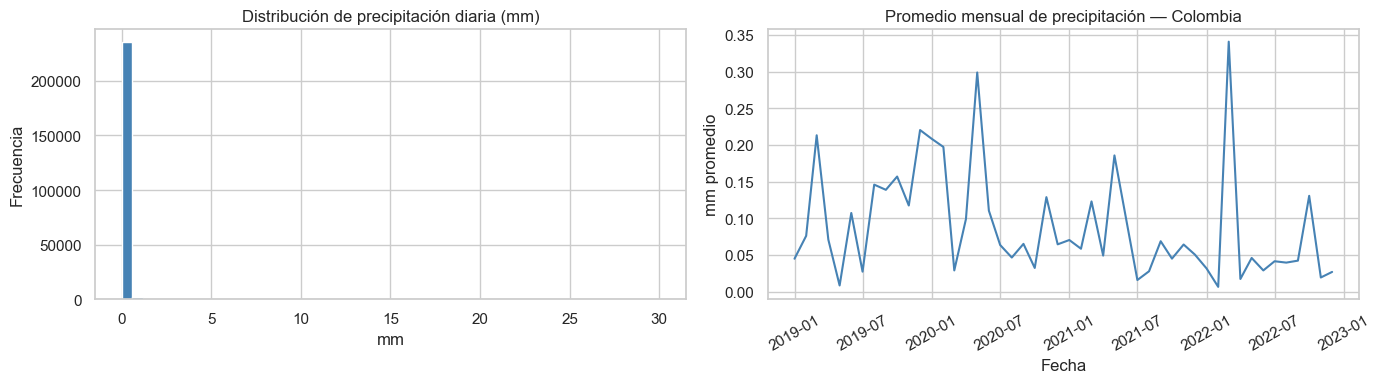


Estaciones/registros por departamento (top 10):


,n_registros
departamento,
boyaca,22069
cundinamarca,20558
antioquia,17538
caldas,17087
bogota d.c.,13318
tolima,12998
valle del cauca,12893
santander,12858
huila,11754


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de precipitación
axes[0].hist(df_ideam['precip_mm'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de precipitación diaria (mm)')
axes[0].set_xlabel('mm')
axes[0].set_ylabel('Frecuencia')

# Serie temporal promedio mensual
monthly_avg = df_ideam.groupby('anio_mes')['precip_mm'].mean()
monthly_avg.index = monthly_avg.index.to_timestamp()
axes[1].plot(monthly_avg.index, monthly_avg.values, color='steelblue', linewidth=1.5)
axes[1].set_title('Promedio mensual de precipitación — Colombia')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('mm promedio')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\nEstaciones/registros por departamento (top 10):")
display(df_ideam.groupby('departamento').size().sort_values(ascending=False).head(10).to_frame('n_registros'))

### 3.2 Eventos Hidrometeorológicos UNGRD

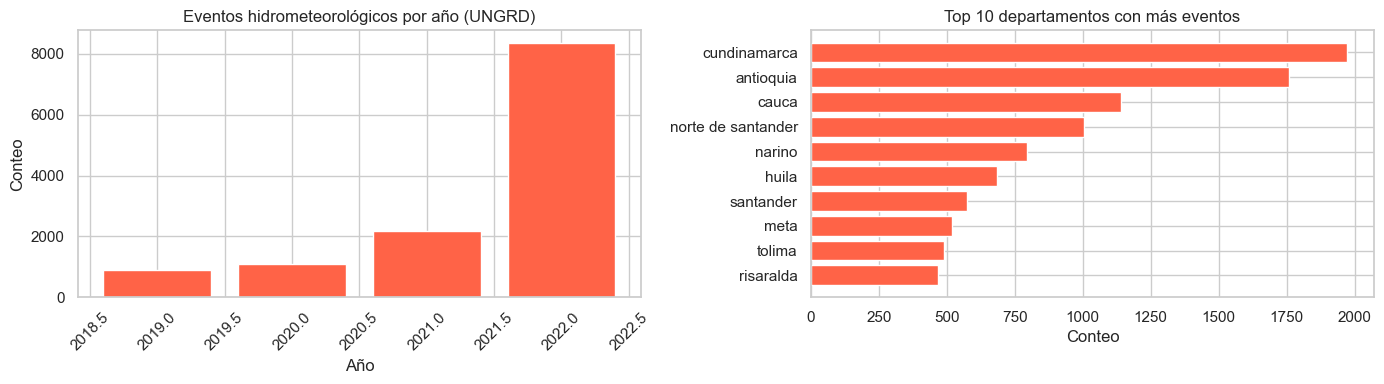

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anual = df_ungrd.groupby('anio').size()
axes[0].bar(anual.index, anual.values, color='tomato', edgecolor='white')
axes[0].set_title('Eventos hidrometeorológicos por año (UNGRD)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Conteo')
axes[0].tick_params(axis='x', rotation=45)

top_dptos = df_ungrd.groupby('departamento').size().sort_values(ascending=False).head(10)
axes[1].barh(top_dptos.index[::-1], top_dptos.values[::-1], color='tomato')
axes[1].set_title('Top 10 departamentos con más eventos')
axes[1].set_xlabel('Conteo')

plt.tight_layout()
plt.show()

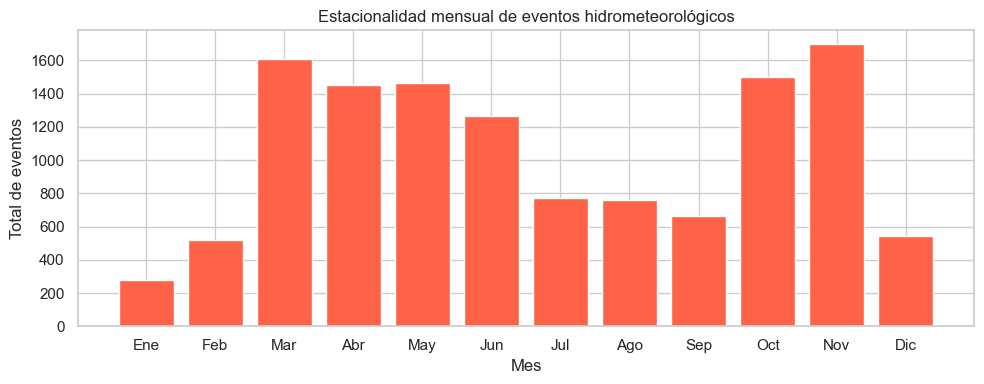

Hipótesis: los meses con mayor precipitación coinciden con más eventos hidrometeorológicos.


In [ ]:
mensual = df_ungrd.groupby('mes').size()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(10, 4))
plt.bar(meses, [mensual.get(i+1, 0) for i in range(12)], color='tomato', edgecolor='white')
plt.title('Estacionalidad mensual de eventos hidrometeorológicos')
plt.xlabel('Mes')
plt.ylabel('Total de eventos')
plt.tight_layout()
plt.show()

print('Hipótesis: los meses con mayor precipitación coinciden con más eventos hidrometeorológicos.')

## 4. Join Espacial-Temporal

Unimos los dos datasets a nivel **(departamento, año-mes)**.

In [ ]:
df_monthly = aggregate_monthly(df_ideam, df_ungrd)
display(df_monthly.head(5))

print(f"\nBalance de clases:")
print(df_monthly['target'].value_counts(normalize=True).rename({0:'sin evento', 1:'con evento'}))

Dataset unido: 1,499 filas | con evento: 855 (57.0%)


,departamento,anio_mes,precip_suma,precip_max,precip_dias_lluvia,n_eventos,target,anio,mes
0,<nil>,2019-01,0.0,0.0,0,0,0,2019,1
1,<nil>,2019-02,0.2,0.2,1,0,0,2019,2
2,<nil>,2019-03,0.4,0.4,1,0,0,2019,3
3,<nil>,2019-04,0.0,0.0,0,0,0,2019,4
4,amazonas,2019-01,0.0,0.0,0,0,0,2019,1



Balance de clases:
target
con evento    0.57038
sin evento    0.42962
Name: proportion, dtype: float64


## 5. Feature Engineering — Acumulados de Precipitación

In [ ]:
df = build_features(df_monthly)
save_processed(df)

FEATURES = ['precip_suma', 'precip_max', 'precip_dias_lluvia',
            'precip_lag1', 'precip_acum3m', 'precip_acum6m', 'precip_max3m']

display(df[FEATURES + ['target']].describe().round(2))

Dataset con features: 1,463 filas listas para correlación
Guardado en D:\Diego\projects\mlops_udem\riesgo-deslizamientos-mlops\data\processed\dataset_correlacion.csv


,precip_suma,precip_max,precip_dias_lluvia,precip_lag1,precip_acum3m,precip_acum6m,precip_max3m,target
count,1463.00,1463.00,1463.00,1463.00,1463.00,1463.00,1463.00,1463.00
mean,14.52,2.03,11.59,14.58,43.17,84.50,3.99,0.58
std,68.28,4.94,26.82,68.29,157.79,282.74,6.49,0.49
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.30,1.61,0.16,0.00
50%,0.28,0.10,2.00,0.23,4.90,15.50,1.00,1.00
75%,4.70,1.14,10.00,4.70,28.24,60.11,5.00,1.00
max,980.40,30.00,405.00,980.40,2371.00,3859.69,30.00,1.00


## 6. Análisis de Correlación

### 6.1 Matriz de correlación (Pearson)

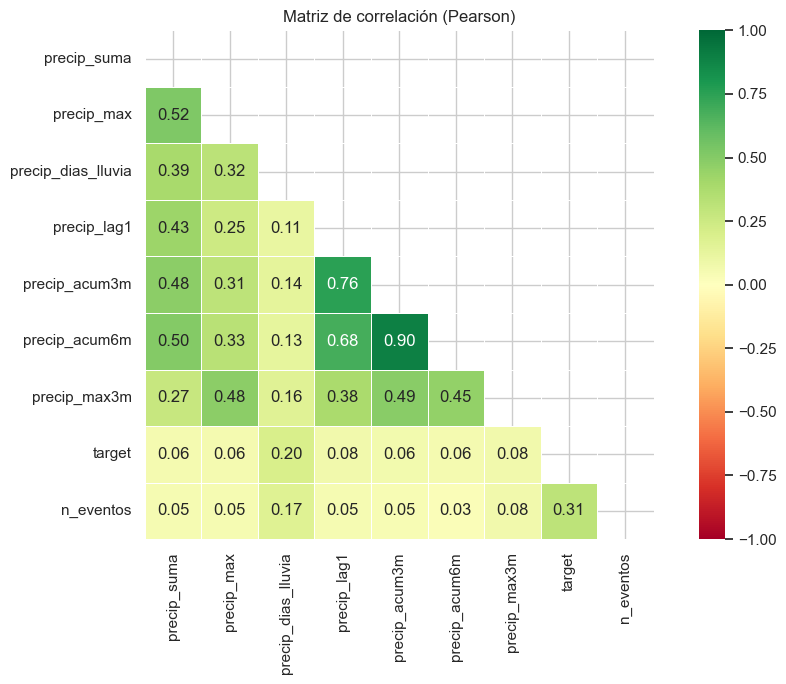

In [ ]:
corr_matrix = df[FEATURES + ['target', 'n_eventos']].corr()

plt.figure(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Matriz de correlación (Pearson)')
plt.tight_layout()
plt.show()

### 6.2 Point-Biserial Correlation con el target binario

In [ ]:
results = []
for feat in FEATURES:
    vals = df[feat].dropna()
    target_aligned = df.loc[vals.index, 'target']
    r, p = stats.pointbiserialr(target_aligned, vals)
    rho, p_spear = stats.spearmanr(vals, target_aligned)
    results.append({'feature': feat, 'r_pointbiserial': r, 'rho_spearman': rho, 'p_value': p})

df_corr = pd.DataFrame(results).sort_values('r_pointbiserial', ascending=False)
df_corr['significativa'] = df_corr['p_value'] < 0.05
display(df_corr.round(4))

,feature,r_pointbiserial,rho_spearman,p_value,significativa
2,precip_dias_lluvia,0.1981,0.3557,0.0000,True
6,precip_max3m,0.0776,0.2486,0.0030,True
3,precip_lag1,0.0759,0.2813,0.0037,True
4,precip_acum3m,0.0638,0.2975,0.0147,True
5,precip_acum6m,0.0612,0.3258,0.0191,True
1,precip_max,0.0607,0.2830,0.0202,True
0,precip_suma,0.0598,0.3077,0.0222,True


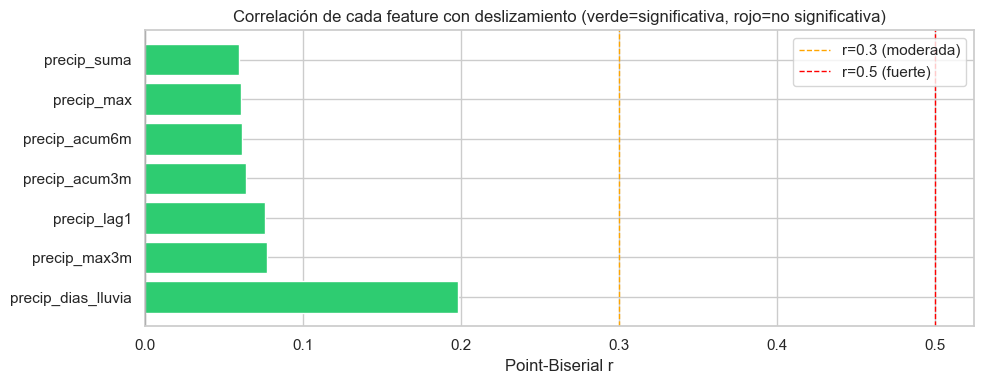

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if sig else '#e74c3c' for sig in df_corr['significativa']]
bars = ax.barh(df_corr['feature'], df_corr['r_pointbiserial'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='orange', linewidth=1, linestyle='--', label='r=0.3 (moderada)')
ax.axvline(0.5,  color='red',    linewidth=1, linestyle='--', label='r=0.5 (fuerte)')
ax.set_xlabel('Point-Biserial r')
ax.set_title('Correlación de cada feature con deslizamiento (verde=significativa, rojo=no significativa)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Boxplot — Precipitación en meses con y sin deslizamiento

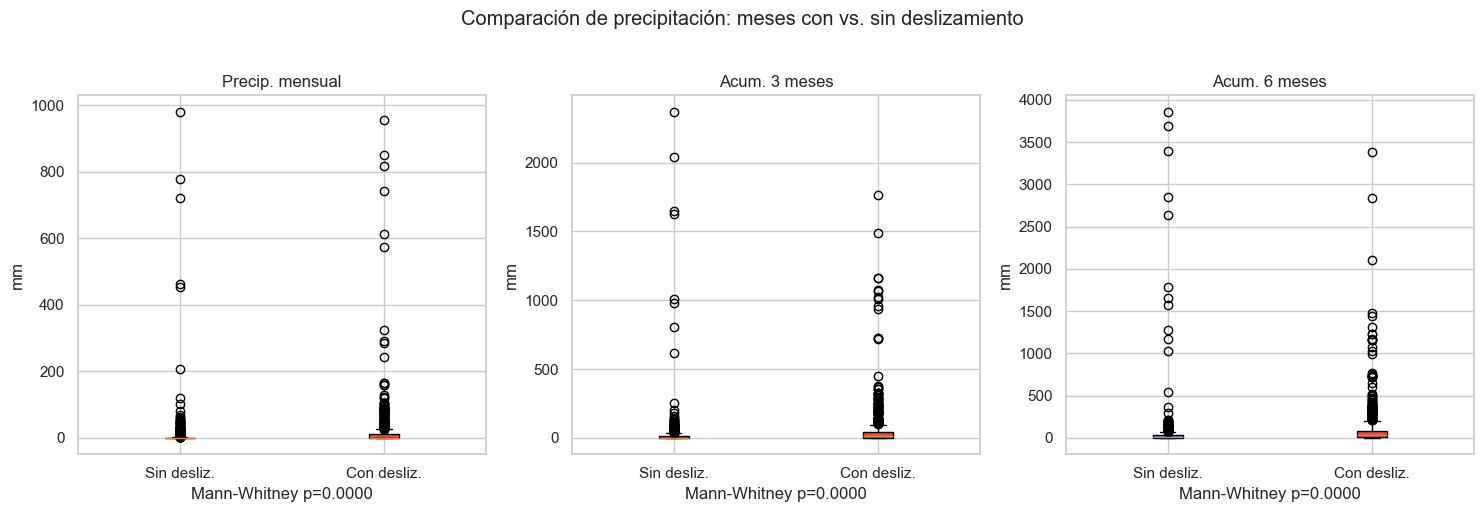

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feats_box = ['precip_suma', 'precip_acum3m', 'precip_acum6m']
labels_map = {'precip_suma': 'Precip. mensual', 'precip_acum3m': 'Acum. 3 meses', 'precip_acum6m': 'Acum. 6 meses'}

for ax, feat in zip(axes, feats_box):
    groups = [df.loc[df['target']==0, feat].dropna(), df.loc[df['target']==1, feat].dropna()]
    bp = ax.boxplot(groups, labels=['Sin desliz.', 'Con desliz.'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(labels_map[feat])
    ax.set_ylabel('mm')
    # Mann-Whitney U test
    u_stat, p_val = stats.mannwhitneyu(*groups, alternative='two-sided')
    ax.set_xlabel(f'Mann-Whitney p={p_val:.4f}')

plt.suptitle('Comparación de precipitación: meses con vs. sin deslizamiento', y=1.02)
plt.tight_layout()
plt.show()

## 7. Modelo Simple de Validación — Regresión Logística

In [ ]:
df_model = df[FEATURES + ['target']].dropna()
X = df_model[FEATURES]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
model.fit(X_train_sc, y_train)

y_prob = model.predict_proba(X_test_sc)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {auc:.4f}')
print(f'(Baseline = 0.50 | Bueno >= 0.65 | Fuerte >= 0.75)')

ROC-AUC: 0.6948
(Baseline = 0.50 | Bueno >= 0.65 | Fuerte >= 0.75)


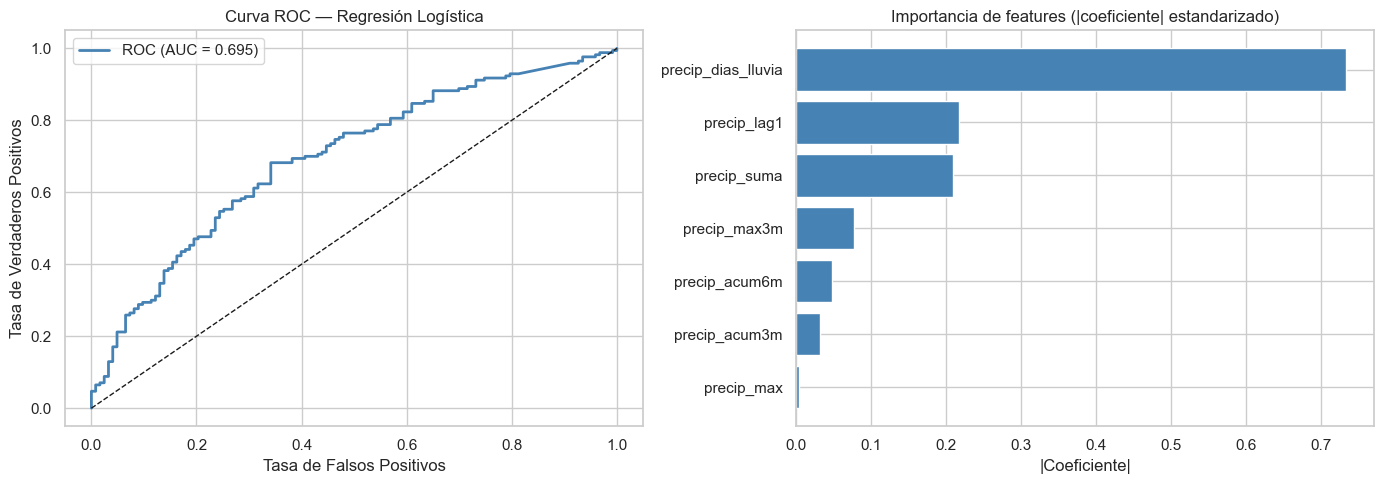

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Regresión Logística')
axes[0].legend()

# Importancia de coeficientes
coefs = pd.Series(np.abs(model.coef_[0]), index=FEATURES).sort_values(ascending=True)
axes[1].barh(coefs.index, coefs.values, color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de features (|coeficiente| estandarizado)')
axes[1].set_xlabel('|Coeficiente|')

plt.tight_layout()
plt.show()

## 8. Conclusiones del Experimento

In [ ]:
mejor_feature = df_corr.iloc[0]
auc_interpretacion = 'FUERTE' if auc >= 0.75 else ('MODERADA' if auc >= 0.65 else 'DÉBIL')

print('=' * 60)
print('RESUMEN DEL EXPERIMENTO DE CORRELACIÓN')
print('=' * 60)
print(f"\n Dataset IDEAM:  {len(df_ideam):,} registros de precipitación")
print(f" Dataset UNGRD:  {len(df_ungrd):,} eventos hidrometeorológicos")
print(f" Dataset unido:  {len(df):,} filas (departamento × mes)")
print(f" Positivos:      {df['target'].mean():.1%} de los meses tienen ≥1 evento")
print(f"\n Mejor feature:      {mejor_feature['feature']}")
print(f" r point-biserial:   {mejor_feature['r_pointbiserial']:.4f}")
print(f" rho Spearman:       {mejor_feature['rho_spearman']:.4f}")
print(f" p-value:            {mejor_feature['p_value']:.4e}")
print(f"\n ROC-AUC modelo:     {auc:.4f} ({auc_interpretacion})")
print()

if auc >= 0.65 or abs(mejor_feature['r_pointbiserial']) >= 0.3:
    print(' CONCLUSIÓN: La precipitación tiene correlación SUFICIENTE con los')
    print(' eventos hidrometeorológicos para justificar el proyecto completo.')
    print(' El proyecto BLINDAJE DEL TERRITORIO es VIABLE.')
else:
    print(' CONCLUSIÓN: La correlación es débil con los datos actuales.')
    print(' Considerar incorporar más variables (suelo, pendiente, días consecutivos de lluvia).')

print('=' * 60)

RESUMEN DEL EXPERIMENTO DE CORRELACIÓN

 Dataset IDEAM:  240,000 registros de precipitación
 Dataset UNGRD:  12,525 eventos hidrometeorológicos
 Dataset unido:  1,463 filas (departamento × mes)
 Positivos:      58.0% de los meses tienen ≥1 evento

 Mejor feature:      precip_dias_lluvia
 r point-biserial:   0.1981
 rho Spearman:       0.3557
 p-value:            2.0904e-14

 ROC-AUC modelo:     0.6948 (MODERADA)

 CONCLUSIÓN: La precipitación tiene correlación SUFICIENTE con los
 eventos hidrometeorológicos para justificar el proyecto completo.
 El proyecto BLINDAJE DEL TERRITORIO es VIABLE.
